In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression,BayesianRidge
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier,GradientBoostingRegressor
from sklearn.model_selection import cross_val_score,train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score,accuracy_score,confusion_matrix,recall_score, precision_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from xgboost import XGBRegressor

In [ ]:
df=pd.read_csv('alzheimers_prediction_dataset.csv')
df.head(5)

,Country,Age,Gender,Education Level,BMI,Physical Activity Level,Smoking Status,Alcohol Consumption,Diabetes,Hypertension,...,Dietary Habits,Air Pollution Exposure,Employment Status,Marital Status,Genetic Risk Factor (APOE-ε4 allele),Social Engagement Level,Income Level,Stress Levels,Urban vs Rural Living,Alzheimer’s Diagnosis
0,Spain,90,Male,1,33.0,Medium,Never,Occasionally,No,No,...,Healthy,High,Retired,Single,No,Low,Medium,High,Urban,No
1,Argentina,72,Male,7,29.9,Medium,Former,Never,No,No,...,Healthy,Medium,Unemployed,Widowed,No,High,Low,High,Urban,No
2,South Africa,86,Female,19,22.9,High,Current,Occasionally,No,Yes,...,Average,Medium,Employed,Single,No,Low,Medium,High,Rural,No
3,China,53,Male,17,31.2,Low,Never,Regularly,Yes,No,...,Healthy,Medium,Retired,Single,No,High,Medium,Low,Rural,No
4,Sweden,58,Female,3,30.0,High,Former,Never,Yes,No,...,Unhealthy,High,Employed,Married,No,Low,Medium,High,Rural,No


In [ ]:
print(df.shape)
print(df.info())

(74283, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Country                               74283 non-null  object 
 1   Age                                   74283 non-null  int64  
 2   Gender                                74283 non-null  object 
 3   Education Level                       74283 non-null  int64  
 4   BMI                                   74283 non-null  float64
 5   Physical Activity Level               74283 non-null  object 
 6   Smoking Status                        74283 non-null  object 
 7   Alcohol Consumption                   74283 non-null  object 
 8   Diabetes                              74283 non-null  object 
 9   Hypertension                          74283 non-null  object 
 10  Cholesterol Level                     74283 non-null  object 
 11  Fam

In [ ]:
print(df.columns)
for col in df.columns:
    print(col)
    print(df[col].unique())

Index(['Country', 'Age', 'Gender', 'Education Level', 'BMI',
       'Physical Activity Level', 'Smoking Status', 'Alcohol Consumption',
       'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Family History of Alzheimer’s', 'Cognitive Test Score',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Employment Status', 'Marital Status',
       'Genetic Risk Factor (APOE-ε4 allele)', 'Social Engagement Level',
       'Income Level', 'Stress Levels', 'Urban vs Rural Living',
       'Alzheimer’s Diagnosis'],
      dtype='object')
Country
['Spain' 'Argentina' 'South Africa' 'China' 'Sweden' 'South Korea'
 'Germany' 'UK' 'Canada' 'India' 'Italy' 'USA' 'Russia' 'Japan'
 'Australia' 'France' 'Norway' 'Saudi Arabia' 'Mexico' 'Brazil']
Age
[90 72 86 53 58 55 91 67 84 80 69 56 61 64 51 60 82 63 76 87 89 73 68 57
 77 62 59 50 88 78 52 74 70 75 65 81 94 79 93 92 83 85 71 66 54]
Gender
['Male' 'Female']
Education Level
[ 1  7 19 17  3  2 18 11 15 1

In [ ]:
#Tiền xử lí sơ bộ
print(df.isnull().sum())
le=LabelEncoder()
for col in df.columns:
    if df[col].nunique()==2:
        df[col]=le.fit_transform(df[col])
map={'Low':2, 'Medium':1, 'High':0}
df['Social Engagement Level']=df['Social Engagement Level'].map(map)
df['Physical Activity Level']=df['Physical Activity Level'].map(map)
map={'Low':0, 'Medium':1, 'High':2}
df['Depression Level']=df['Depression Level'].map(map)
df['Air Pollution Exposure']=df['Air Pollution Exposure'].map(map)

df['Income Level']=df['Income Level'].map(map)
df['Stress Levels']=df['Stress Levels'].map(map)
map={'Never':0,'Former':1,'Current':2}
df['Smoking Status']=df['Smoking Status'].map(map)
map={'Poor':2,'Average':1,'Good':0}
df['Sleep Quality']=df['Sleep Quality'].map(map)
map={'Never':0,'Occasionally':1,'Regularly':2}
df['Alcohol Consumption']=df['Alcohol Consumption'].map(map)
map={'Unhealthy':2,'Average':1,'Healthy':0}
df['Dietary Habits']=df['Dietary Habits'].map(map)
map={'Unemployed':0,'Retired':1,'Employed':2}
df['Employment Status']=df['Employment Status'].map(map)
map={'Single':0,'Widowed':1,'Married':2}
df['Marital Status']=df['Marital Status'].map(map)
print(df.head(5))
print(df.isnull().sum())

Country                                 0
Age                                     0
Gender                                  0
Education Level                         0
BMI                                     0
Physical Activity Level                 0
Smoking Status                          0
Alcohol Consumption                     0
Diabetes                                0
Hypertension                            0
Cholesterol Level                       0
Family History of Alzheimer’s           0
Cognitive Test Score                    0
Depression Level                        0
Sleep Quality                           0
Dietary Habits                          0
Air Pollution Exposure                  0
Employment Status                       0
Marital Status                          0
Genetic Risk Factor (APOE-ε4 allele)    0
Social Engagement Level                 0
Income Level                            0
Stress Levels                           0
Urban vs Rural Living             

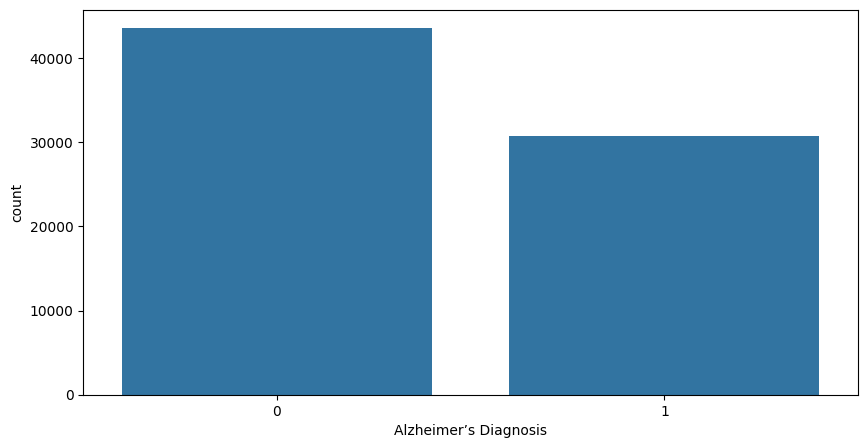

Alzheimer’s Diagnosis
0    43570
1    30713
Name: count, dtype: int64


In [ ]:
#Phân tích số lượng target
fig,ax=plt.subplots(figsize=(10,5))
sns.countplot(x='Alzheimer’s Diagnosis',data=df)
plt.show()
soluong=df['Alzheimer’s Diagnosis'].value_counts()
print(soluong)

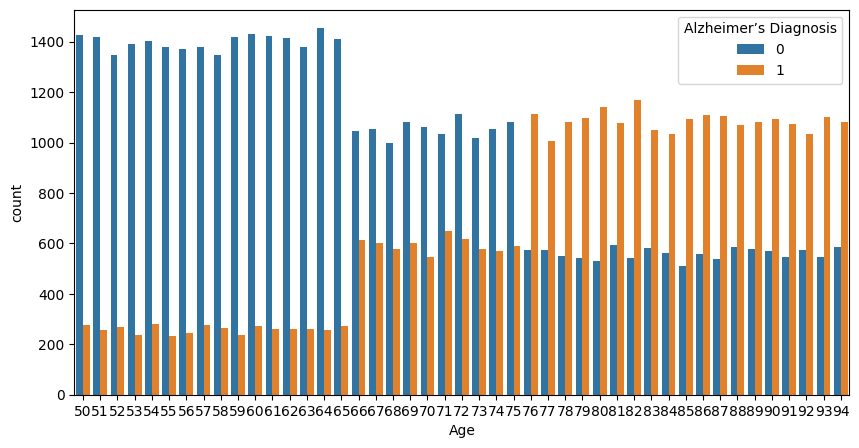

In [ ]:
#AGE
fig,ax=plt.subplots(figsize=(10,5))
sns.countplot(x='Age',hue='Alzheimer’s Diagnosis',data=df)
plt.show()

In [ ]:
age_bins = [0,66,76,100]
age_labels = ['65-','66-75','76+']

# Áp dụng binning
df['age_group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)
le=LabelEncoder()
df['age_group']=le.fit_transform(df['age_group'])
print(df.head())

        Country  Age  Gender  Education Level   BMI  Physical Activity Level  \
0         Spain   90       1                1  33.0                        1   
1     Argentina   72       1                7  29.9                        1   
2  South Africa   86       0               19  22.9                        0   
3         China   53       1               17  31.2                        2   
4        Sweden   58       0                3  30.0                        0   

   Smoking Status  Alcohol Consumption  Diabetes  Hypertension  ...  \
0               0                    1         0             0  ...   
1               1                    0         0             0  ...   
2               2                    1         0             1  ...   
3               0                    2         1             0  ...   
4               1                    0         1             0  ...   

   Air Pollution Exposure  Employment Status  Marital Status  \
0                       2   

['Age', 'BMI', 'Cognitive Test Score', 'Education Level', 'Alzheimer’s Diagnosis']


<Axes: >

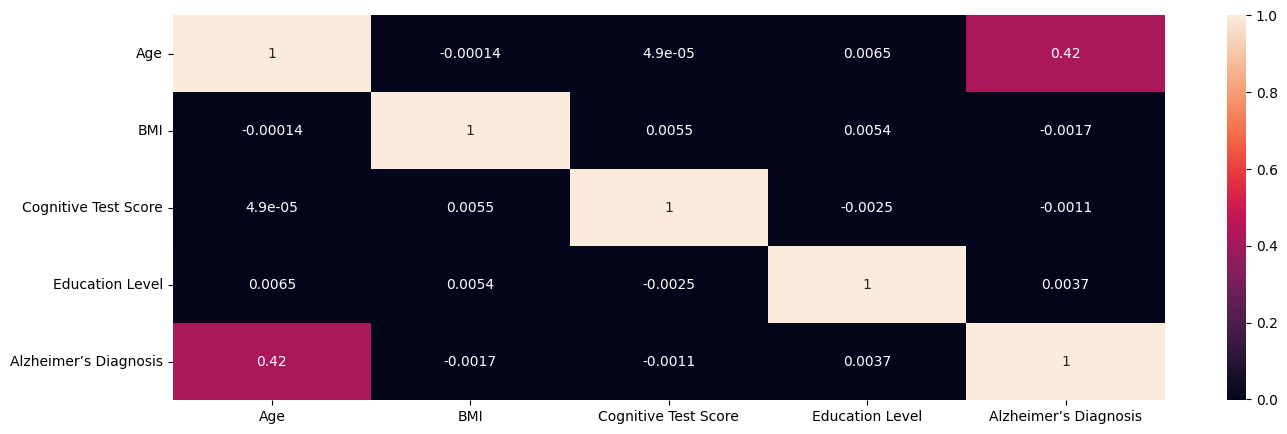

In [ ]:
#Phân tích heatmap các feature quan trọng
fig,ax=plt.subplots(figsize=(16,5))
list_importance=['Age','BMI','Cognitive Test Score','Education Level','Alzheimer’s Diagnosis']
print(list_importance)
sns.heatmap(df[list_importance].corr(),annot=True)

<Axes: xlabel='Cognitive Test Score', ylabel='Alzheimer’s Diagnosis'>

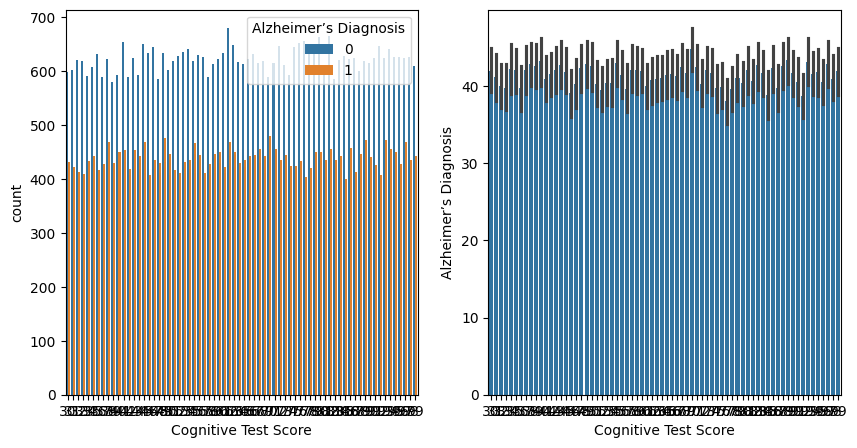

In [ ]:
#Cognitive Test Score
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.countplot(data=df,x='Cognitive Test Score',hue='Alzheimer’s Diagnosis',ax=ax[0])
sns
sns.barplot(data=df, x='Cognitive Test Score', y='Alzheimer’s Diagnosis',
            estimator=lambda x: np.mean(x)*100,ax=ax[1],
            errorbar=('ci', 95))

In [ ]:
cog_bins = [0,25,50,75,100]
cog_labels = ['0','1','2','3']

# Áp dụng binning
df['cog_group'] = pd.cut(df['Cognitive Test Score'], bins=cog_bins, labels=cog_labels, right=False)
map_cog={
    '0':0,
    '1':1,
    '2':2,
    '3':3,
}
df['cog_group']=df['cog_group'].map(map_cog)
df['cog_group'] = df['cog_group'].astype('int64')


print(df[['Cognitive Test Score','cog_group']].head())
print(df[['Cognitive Test Score','cog_group']].info())

   Cognitive Test Score  cog_group
0                    90          3
1                    65          2
2                    43          1
3                    81          3
4                    49          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74283 entries, 0 to 74282
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Cognitive Test Score  74283 non-null  int64
 1   cog_group             74283 non-null  int64
dtypes: int64(2)
memory usage: 1.1 MB
None


<Axes: xlabel='cog_group', ylabel='Alzheimer’s Diagnosis'>

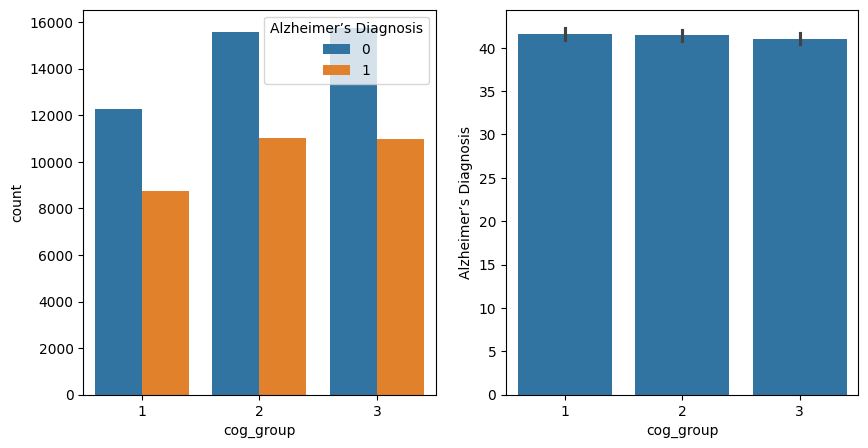

In [ ]:
#Cognitive Test Score
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.countplot(data=df,x='cog_group',hue='Alzheimer’s Diagnosis',ax=ax[0])
sns
sns.barplot(data=df, x='cog_group', y='Alzheimer’s Diagnosis',
            estimator=lambda x: np.mean(x)*100,ax=ax[1],
            errorbar=('ci', 95))

<Axes: xlabel='Education Level', ylabel='Alzheimer’s Diagnosis'>

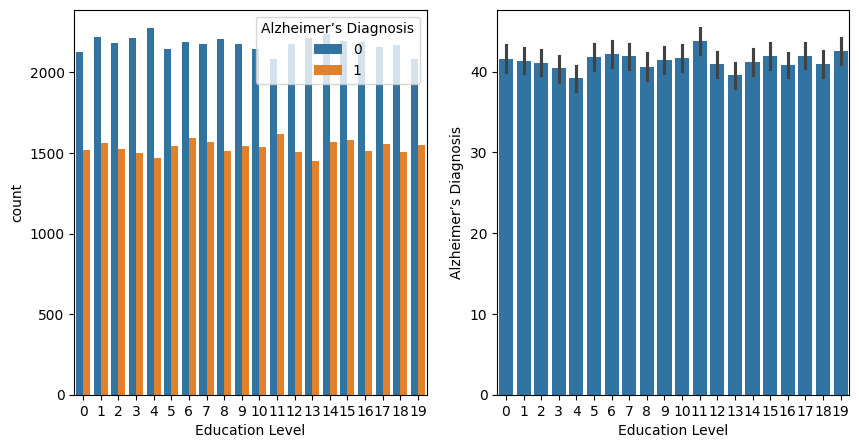

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
sns.countplot(data=df,x='Education Level',hue='Alzheimer’s Diagnosis',ax=ax[0])
sns.barplot(data=df, x='Education Level', y='Alzheimer’s Diagnosis',
            estimator=lambda x: np.mean(x)*100,ax=ax[1],
            errorbar=('ci', 95))

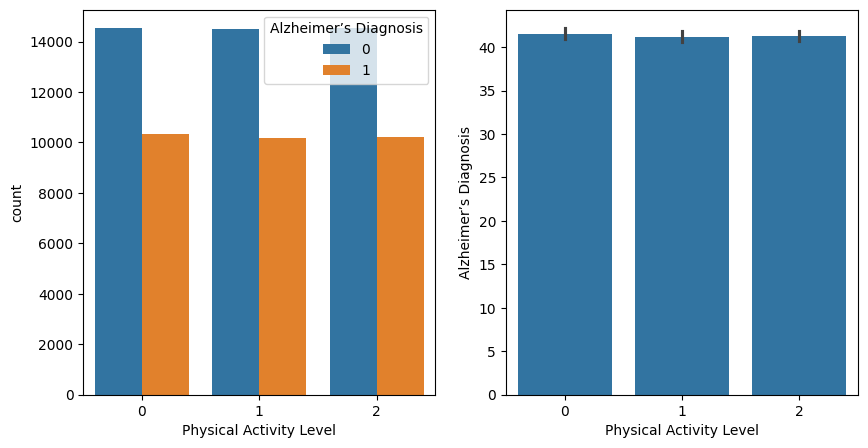

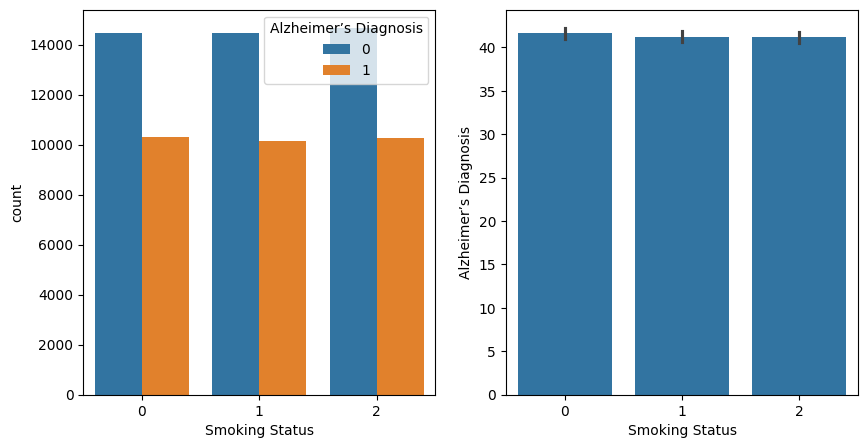

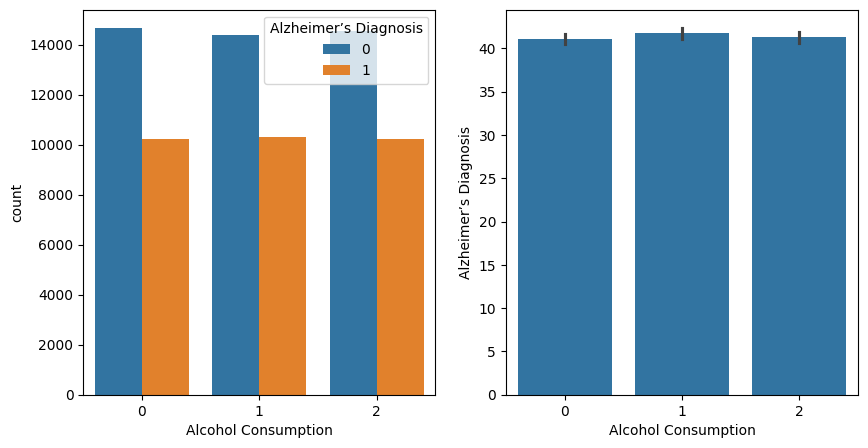

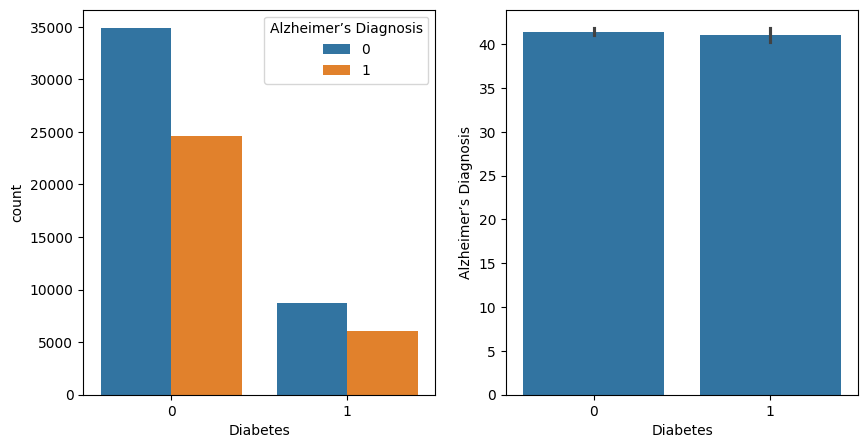

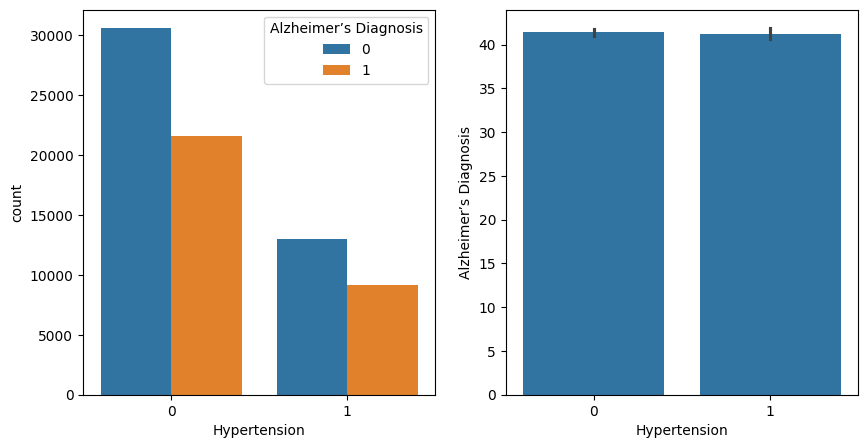

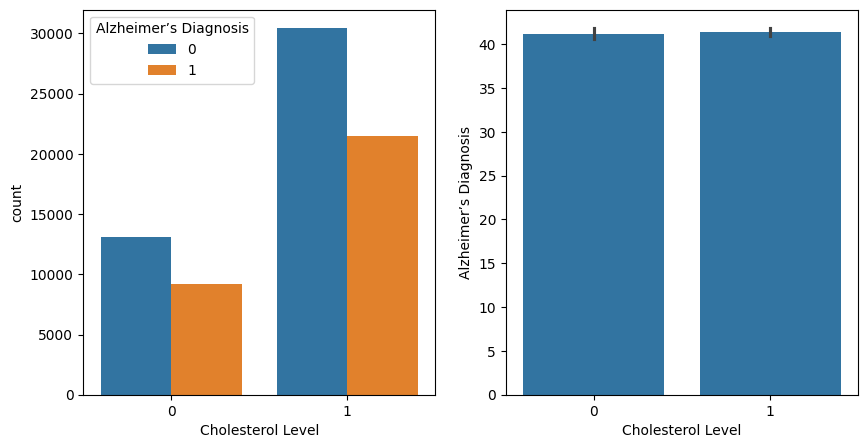

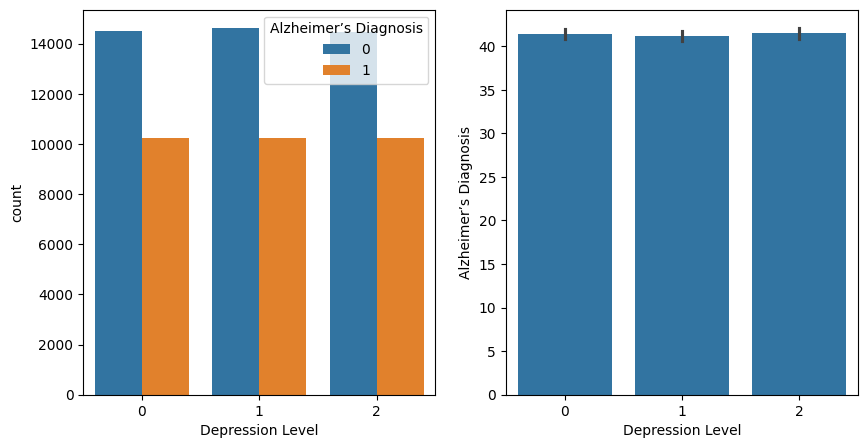

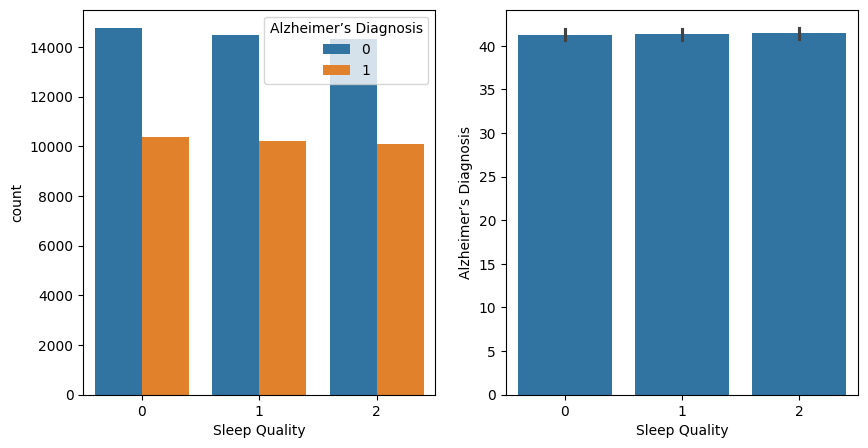

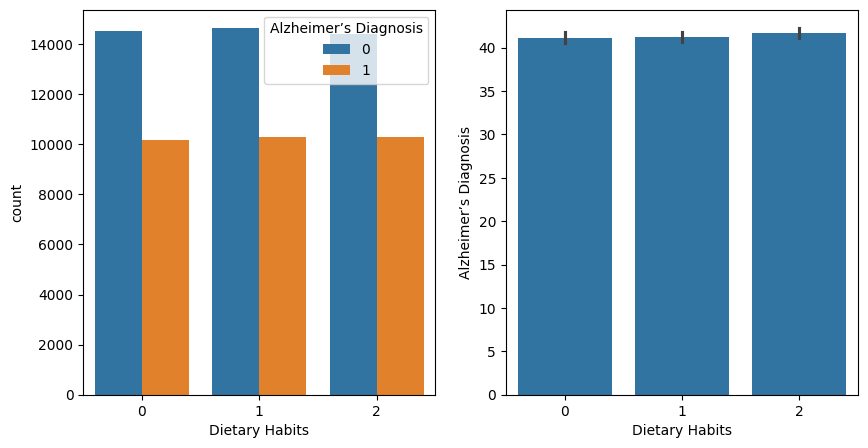

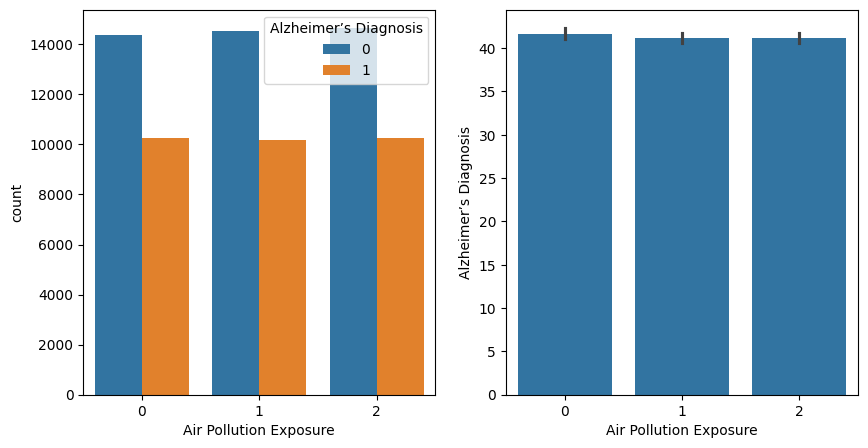

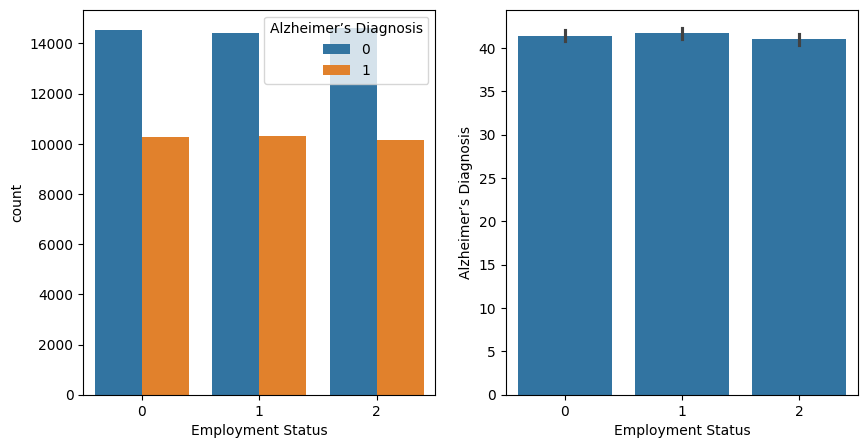

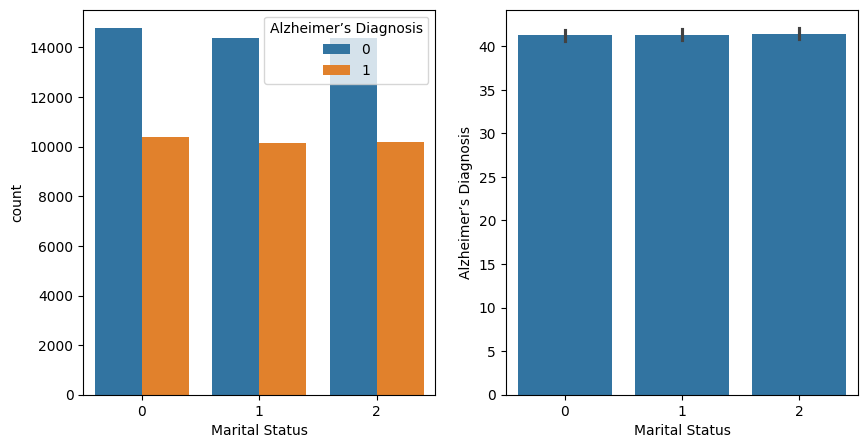

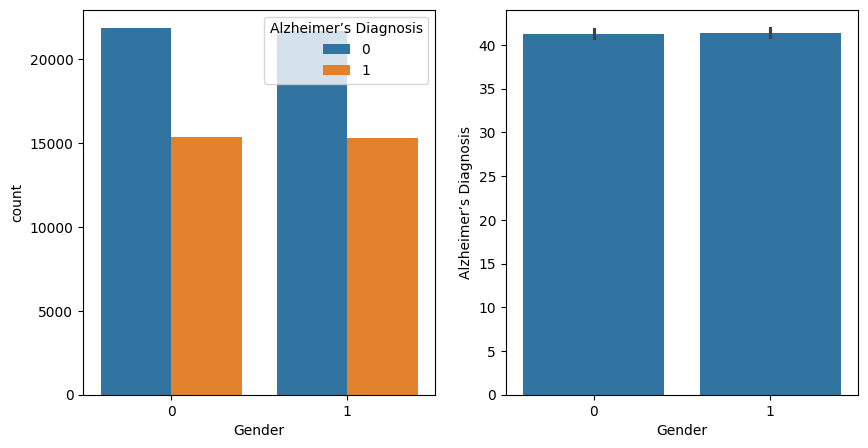

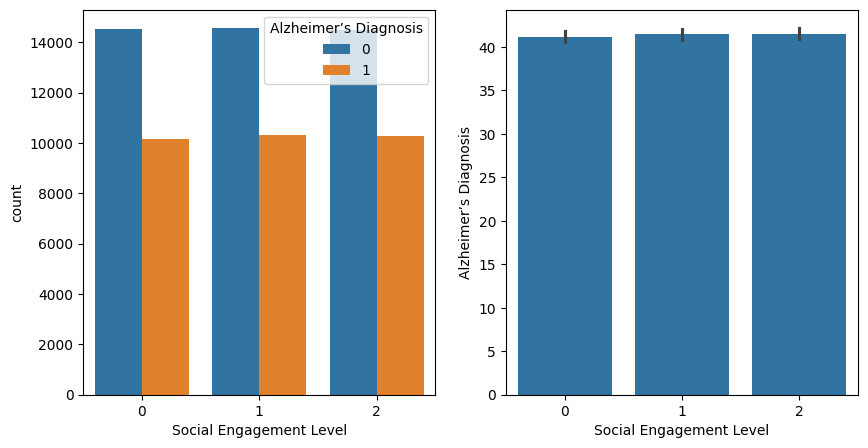

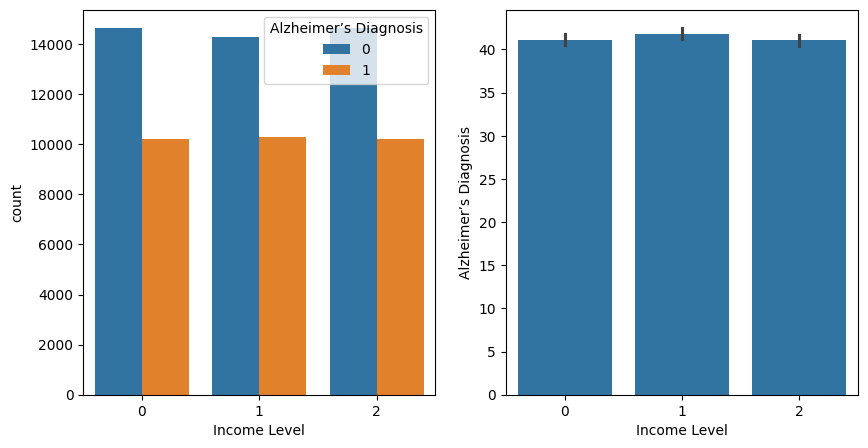

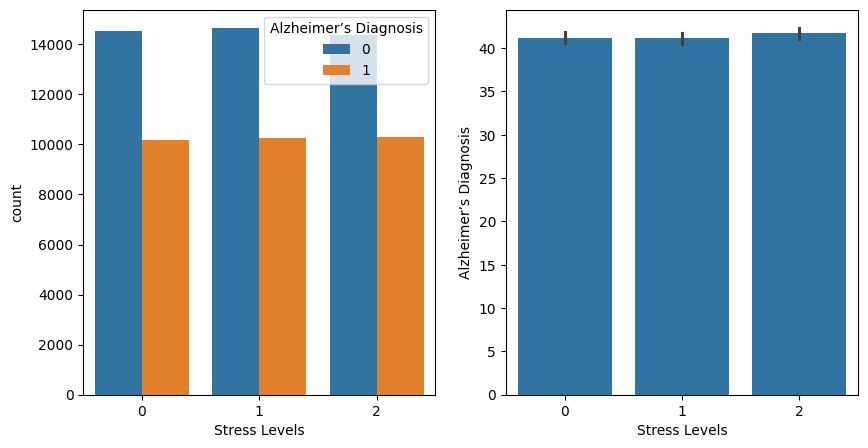

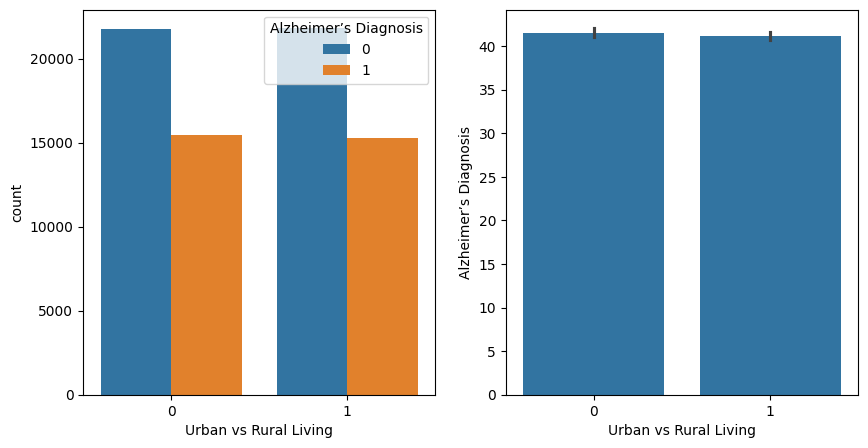

In [ ]:
#Phân tích các feature còn lại
def plot(df,col):
  fig,ax=plt.subplots(1,2,figsize=(10,5))
  sns.countplot(x=col,hue='Alzheimer’s Diagnosis',data=df,ax=ax[0])
  sns.barplot(data=df, x=col, y='Alzheimer’s Diagnosis',
            estimator=lambda x: np.mean(x)*100,ax=ax[1],
            errorbar=('ci', 95))
  plt.show()
feature_list=[
    'Physical Activity Level',
'Smoking Status',
'Alcohol Consumption',
'Diabetes',
'Hypertension',
'Cholesterol Level',
'Depression Level',
'Sleep Quality',
'Dietary Habits',
'Air Pollution Exposure',
'Employment Status',
'Marital Status',
'Gender',
'Social Engagement Level',
'Income Level',
'Stress Levels',

'Urban vs Rural Living',  ]
for col in feature_list:
  plot(df,col)

In [ ]:
from sklearn.metrics import log_loss
from sklearn.model_selection import cross_val_score
#Phân tích các feature tuyến tính

X_log=df[['Age','Genetic Risk Factor (APOE-ε4 allele)','Family History of Alzheimer’s']]
y_log=df['Alzheimer’s Diagnosis']
error_list=[]
dict_group = {
    '0-5%':[],
    '5-10%':[],
    '10-15%':[],
    '15-20%':[],
    '20-25%':[],
    '25-30%':[],
    '30-35%':[],
    '35-40%':[],
    '40-45%':[],
    '45-50%':[],
    '50-55%':[],
     '55-60%':[],
      '60-65%':[],
     '65-70%':[],
    '70-75%':[],
    '75-80%':[],
    '80-85%':[],
    '85-90%':[],
    '90-95%':[],
    '95-100%':[]
}
dict_bieudo={
    'group':[],
    'pre':[],
    'actual':[],
}
X_train,X_test,y_train,y_test=train_test_split(X_log,y_log,test_size=0.2,random_state=11)
scaler = StandardScaler()
X_train_log =scaler.fit_transform(X_train)
X_test_log =scaler.transform(X_test)

model = LogisticRegression(
  max_iter=1000,
  class_weight='balanced' ,
  solver= 'newton-cg')
model.fit(X_train_log,y_train)

y_pred = model.predict(X_test_log)

print('mae ' , mean_absolute_error(y_test,y_pred))
print('accuracy ',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print('recall' ,recall_score(y_test,y_pred))
print('precision ',precision_score(y_test,y_pred))
print('auc ' ,roc_auc_score(y_test,y_pred))
print('f1 ',f1_score(y_test,y_pred))
#phân tích prob
from sklearn.calibration import CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(
    model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_train_log, y_train)

X_test['pred_prob']=calibrated_model.predict_proba(X_test_log)[:,1]
bins = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1]
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '25-30%', '30-35%', '35-40%', '40-45%', '45-50%',
          '50-55%', '55-60%',
           '60-65%', '65-70%','70-75%', '75-80%', '80-85%','85-90%','90-95%','95-100%']

X_test['pred_group'] = pd.cut(X_test['pred_prob'], bins=bins, labels=labels)
X_test['target']=y_test
  #Tính toán từng bin
all_groups = X_test['pred_group'].dropna().unique()
for group in sorted(all_groups):
    # Lọc ra những người trong nhóm này
    mask = X_test['pred_group'] == group
    group_data = X_test[mask]

    # Tính:
    n_people = len(group_data)  # Số người trong nhóm
    avg_pred = group_data['pred_prob'].mean()  # Model dự đoán trung bình bao nhiêu %

    # % THỰC TẾ: bao nhiêu % người trong nhóm có target=1
    # Công thức: (số người target=1) / (tổng số người)
    n_target_1 = group_data['target'].sum()  # Số người target=1 (vì target=0/1)
    actual_pct = n_target_1 / n_people if n_people > 0 else 0

    # Tính sai số
    error = abs(avg_pred - actual_pct)
    error_list.append(error)
    dict_group[group].append(error)
    dict_bieudo['group'].append(group)
    dict_bieudo['pre'].append(avg_pred)
    dict_bieudo['actual'].append(actual_pct)

dict_mean={}
for col in dict_group.keys():
  dict_mean[col]=np.mean(dict_group[col])*100

mae  0.2808103924076193
accuracy  0.7191896075923807
[[6186 2473]
 [1699 4499]]
recall 0.7258793159083575
precision  0.6452954675846242
auc  0.720140258485418
f1  0.6832194381169324


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
print(pd.DataFrame([dict_mean]))

mean_value = np.nanmean(list(dict_mean.values()))
print(mean_value)

   0-5%     5-10%    10-15%    15-20%    20-25%    25-30%    30-35%  \
0   NaN  1.986626  3.481211  3.032687  4.036005  3.914874  5.402564   

      35-40%    40-45%   45-50%    50-55%    55-60%    60-65%    65-70%  \
0  11.746569  7.562269  5.58431  2.951212  0.800025  0.424722  1.708861   

     70-75%    75-80%    80-85%    85-90%    90-95%  95-100%  
0  5.217223  2.276368  0.760954  2.899695  1.696722      NaN  
3.6379386707349064


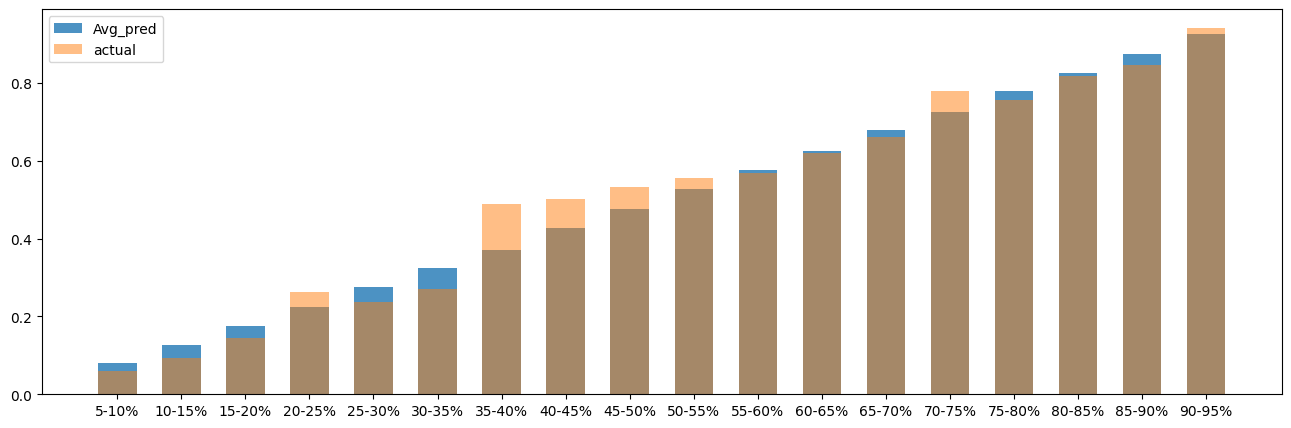

In [ ]:
df_bieudo=pd.DataFrame(dict_bieudo).sort_values(by='pre')
plt.figure(figsize=(16, 5))

plt.bar(df_bieudo['group'], df_bieudo['pre'], width=0.6, label="Avg_pred", alpha=0.8)
plt.bar(df_bieudo['group'], df_bieudo['actual'], width=0.6, label="actual", alpha=0.5)
plt.legend()
plt.show()


In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
error_list=[]
dict_group = {
    '0-5%':[],
    '5-10%':[],
    '10-15%':[],
    '15-20%':[],
    '20-25%':[],
    '25-30%':[],
    '30-35%':[],
    '35-40%':[],
    '40-45%':[],
    '45-50%':[],
    '50-55%':[],
     '55-60%':[],
      '60-65%':[],
     '65-70%':[],
    '70-75%':[],
    '75-80%':[],
    '80-85%':[],
    '85-90%':[],
    '90-95%':[],
    '95-100%':[]
}
healthy_count = sum(y_train == 0)
disease_count = sum(y_train == 1)
imbalance_ratio = healthy_count / disease_count
model_2=XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
     scale_pos_weight=imbalance_ratio ,
    eval_metric='logloss'
)


X=df[['Age','Family History of Alzheimer’s','Genetic Risk Factor (APOE-ε4 allele)','BMI','Education Level','cog_group',
      'Physical Activity Level',
'Smoking Status',
'Alcohol Consumption',
'Diabetes',
'Hypertension',
'Cholesterol Level',
'Depression Level',
'Sleep Quality',
'Dietary Habits',
'Air Pollution Exposure',
'Employment Status',
'Marital Status',
'Gender',
'Social Engagement Level',
'Income Level',
'Stress Levels',

'Urban vs Rural Living',


]]
y=df['Alzheimer’s Diagnosis']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=11)
model_2.fit(X_train,y_train)
y_pred = model_2.predict(X_test)
print (accuracy_score(y_test,y_pred))
from sklearn.calibration import CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(
  model_2,
  method='isotonic',
  cv=5
)
calibrated_model.fit(X_train, y_train)

X_test['pred_prob']=calibrated_model.predict_proba(X_test)[:,1]
bins = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1]
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '25-30%', '30-35%', '35-40%', '40-45%', '45-50%',
          '50-55%', '55-60%',
           '60-65%', '65-70%','70-75%', '75-80%', '80-85%','85-90%','90-95%','95-100%']

X_test['pred_group'] = pd.cut(X_test['pred_prob'], bins=bins, labels=labels)
X_test['target']=y_test
  #Tính toán từng bin
all_groups = X_test['pred_group'].dropna().unique()
for group in sorted(all_groups):
    # Lọc ra những người trong nhóm này
      mask = X_test['pred_group'] == group
      group_data = X_test[mask]

    # Tính:
      n_people = len(group_data)  # Số người trong nhóm
      avg_pred = group_data['pred_prob'].mean()  # Model dự đoán trung bình bao nhiêu %

    # % THỰC TẾ: bao nhiêu % người trong nhóm có target=1
    # Công thức: (số người target=1) / (tổng số người)
      n_target_1 = group_data['target'].sum()  # Số người target=1 (vì target=0/1)
      actual_pct = n_target_1 / n_people if n_people > 0 else 0

    # Tính sai số
      error = abs(avg_pred - actual_pct)

      error_list.append(error)
      dict_group[group].append(error)

dict_mean={}
for col in dict_group.keys():
  dict_mean[col]=np.mean(dict_group[col])*100


print(np.mean(error_list))
print(np.percentile(error_list, 80))
print(pd.DataFrame([dict_mean]))

0.7283435417648246
0.021848388919025345
0.030148750297687755
       0-5%     5-10%    10-15%    15-20%    20-25%    25-30%    30-35%  \
0  6.585198  0.506049  1.229174  0.033788  1.801002  0.001474  2.043263   

    35-40%    40-45%    45-50%    50-55%    55-60%    60-65%    65-70%  \
0  8.27157  3.099695  1.809142  2.277284  0.081931  1.580509  1.047251   

     70-75%   75-80%    80-85%    85-90%    90-95%   95-100%  
0  3.030651  2.79711  1.789493  2.246291  0.454972  3.010931  


Sau khi thêm thì thêm những feature quan trọng , thấy được 1 số bin giảm error, nhưng vẫn còn 1 số bin sai số hơn 8%, cần loại bỏ các feature ko quan trọng, gây nhiễu

In [ ]:
X_kiemtra=X

In [ ]:
X=X_kiemtra.drop(['Income Level','Employment Status','Marital Status'],axis=1)
error_list=[]
dict_group = {
    '0-5%':[],
    '5-10%':[],
    '10-15%':[],
    '15-20%':[],
    '20-25%':[],
    '25-30%':[],
    '30-35%':[],
    '35-40%':[],
    '40-45%':[],
    '45-50%':[],
    '50-55%':[],
     '55-60%':[],
      '60-65%':[],
     '65-70%':[],
    '70-75%':[],
    '75-80%':[],
    '80-85%':[],
    '85-90%':[],
    '90-95%':[],
    '95-100%':[]
}


X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=11)
model_2.fit(X_train,y_train)
y_pred = model_2.predict(X_test)

from sklearn.calibration import CalibratedClassifierCV
calibrated_model = CalibratedClassifierCV(
    model_2,
    method='isotonic',
    cv=5
)
calibrated_model.fit(X_train, y_train)

X_test['pred_prob']=calibrated_model.predict_proba(X_test)[:,1]
bins = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1]
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '25-30%', '30-35%', '35-40%', '40-45%', '45-50%',
          '50-55%', '55-60%',
           '60-65%', '65-70%','70-75%', '75-80%', '80-85%','85-90%','90-95%','95-100%']

X_test['pred_group'] = pd.cut(X_test['pred_prob'], bins=bins, labels=labels)
X_test['target']=y_test
  #Tính toán từng bin
all_groups = X_test['pred_group'].dropna().unique()
for group in sorted(all_groups):
    # Lọc ra những người trong nhóm này
      mask = X_test['pred_group'] == group
      group_data = X_test[mask]

    # Tính:
      n_people = len(group_data)  # Số người trong nhóm
      avg_pred = group_data['pred_prob'].mean()  # Model dự đoán trung bình bao nhiêu %

    # % THỰC TẾ: bao nhiêu % người trong nhóm có target=1
    # Công thức: (số người target=1) / (tổng số người)
      n_target_1 = group_data['target'].sum()  # Số người target=1 (vì target=0/1)
      actual_pct = n_target_1 / n_people if n_people > 0 else 0

    # Tính sai số
      error = abs(avg_pred - actual_pct)

      error_list.append(error)
      dict_group[group].append(error)

dict_mean={}
for col in dict_group.keys():
  dict_mean[col]=np.mean(dict_group[col])*100


print(np.mean(error_list))
print(np.percentile(error_list, 80))
print(pd.DataFrame([dict_mean]))

0.024888422208994086
0.03458204086241452
       0-5%     5-10%    10-15%    15-20%    20-25%    25-30%    30-35%  \
0  1.290954  0.469682  3.126714  1.865128  1.795442  0.081406  2.152009   

     35-40%    40-45%    45-50%    50-55%    55-60%    60-65%    65-70%  \
0  8.417477  5.741157  3.575864  1.676512  0.537834  1.167956  0.442605   

     70-75%    75-80%    80-85%    85-90%    90-95%   95-100%  
0  3.428789  1.598391  1.415073  5.865002  1.777525  3.351325  


Khi bỏ đi gần như các feature không ảnh hưởng gì đên model




In [ ]:
X_kiemtra=X

In [ ]:
X_kiemtra.columns


Index(['Age', 'Family History of Alzheimer’s',
       'Genetic Risk Factor (APOE-ε4 allele)', 'BMI', 'Education Level',
       'cog_group', 'Physical Activity Level', 'Smoking Status',
       'Alcohol Consumption', 'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Gender', 'Social Engagement Level',
       'Stress Levels', 'Urban vs Rural Living'],
      dtype='object')

In [ ]:
X_final=X_kiemtra

In [ ]:
import xgboost as xgb


In [ ]:
X_final=df[['age_group', 'Family History of Alzheimer’s',
       'Genetic Risk Factor (APOE-ε4 allele)', 'BMI', 'Education Level',
       'cog_group', 'Physical Activity Level', 'Smoking Status',
       'Alcohol Consumption', 'Diabetes', 'Hypertension', 'Cholesterol Level',
       'Depression Level', 'Sleep Quality', 'Dietary Habits',
       'Air Pollution Exposure', 'Gender', 'Social Engagement Level',
       'Stress Levels', 'Urban vs Rural Living']]

In [ ]:
import xgboost as xgb
X_train,X_test,y_train,y_test=train_test_split(X_final,y,test_size=0.2,random_state=11)

healthy_count = sum(y_train == 0)
disease_count = sum(y_train == 1)
imbalance_ratio = healthy_count / disease_count
# 1. TĂNG SAMPLE_WEIGHT
sample_weight = np.ones(len(X_train))

# Lấy feature cột 'feature_name' (thay 'feature_name' bằng tên cột thực tế)
feature_col_stress = X_train['Stress Levels'].values
feature_col_physical= X_train['Physical Activity Level'].values
feature_col_dietary=X_train['Dietary Habits'].values
feature_col_depression=X_train['Depression Level'].values
feature_col_smoke=X_train['Smoking Status'].values
feature_col_air=X_train['Air Pollution Exposure'].values
feature_col_social=X_train['Social Engagement Level'].values
feature_col_sleep=X_train['Sleep Quality'].values
feature_col_alcohol=X_train['Alcohol Consumption'].values
feature_col_diabetes=X_train['Diabetes'].values
feature_col_hypertension=X_train['Hypertension'].values
feature_col_cholestorol=X_train['Cholesterol Level'].values
for i in range(len(X_train)):
    if feature_col_alcohol[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_alcohol[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_alcohol[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_physical[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_physical[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_physical[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_dietary[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_dietary[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_dietary[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_depression[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_depression[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_depression[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_social[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i]  *=1.1
    elif feature_col_social[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i]  *=0.8
    elif feature_col_social[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_sleep[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_sleep[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_sleep[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_smoke[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_smoke[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_smoke[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_air[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_air[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_air[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2

    if feature_col_stress[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_stress[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_stress[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_diabetes[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    if feature_col_hypertension[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    if feature_col_cholestorol[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1

# 2. TĂNG FEATURE_WEIGHT
feature_weights = [1.0] * len(X_train.columns)

# Tìm index của feature trong columns
feature_idx = list(X_train.columns).index('Stress Levels')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] = 1.1
feature_idx = list(X_train.columns).index('Social Engagement Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] = 1.1
feature_idx = list(X_train.columns).index('Sleep Quality')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] = 1.1
feature_idx = list(X_train.columns).index('Alcohol Consumption')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Physical Activity Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Depression Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Dietary Habits')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Alcohol Consumption')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Smoking Status')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Air Pollution Exposure')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Diabetes')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Hypertension')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Cholesterol Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
X_train_array = X_train.values
y_train_array = y_train.values if hasattr(y_train, 'values') else y_train

dtrain = xgb.DMatrix(X_train_array, label=y_train_array, weight=sample_weight)
dtrain.set_info(feature_weights=feature_weights)

# 4. TRAIN MODEL
params = {
    'n_estimators': 150,           # num_boost_round = n_estimators
    'learning_rate': 0.05,
    'max_depth': 6,
    'scale_pos_weight': imbalance_ratio,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',}
model_final = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=params['n_estimators']  # = 150
)
dt=xgb.DMatrix(X_test)
y_test_pred=model_final.predict(dt)
k=accuracy_score(y_test,y_test_pred>0.5)
print(k)

X_test_final=X_test
y_test_final=y_test

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:04:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.7031029144511005


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:04:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


       0-5%     5-10%   10-15%    15-20%   20-25%    25-30%    30-35%  \
0  1.190476  1.021492  0.18254  5.059524  0.92145  1.295581  3.882493   

     35-40%    40-45%    45-50%    50-55%    55-60%    60-65%   65-70%  \
0  1.196274  0.487873  1.248435  4.328791  2.581181  0.108201  2.80381   

     70-75%    75-80%   80-85%    85-90%    90-95%   95-100%  
0  2.853745  1.203739  5.18519  0.653595  0.757579  3.721653  
2.034181222885952


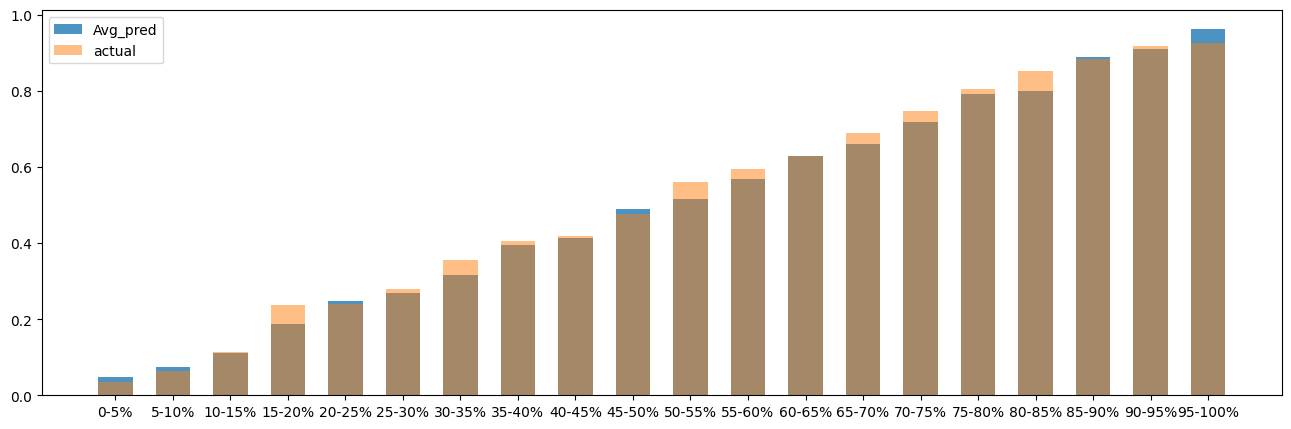

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
X_train,X_test,y_train,y_test=train_test_split(X_final,y,test_size=0.2,random_state=11)
X_train,X_test,y_train,y_test=train_test_split(X_train,y_train,test_size=0.2,random_state=11)
healthy_count = sum(y_train == 0)
disease_count = sum(y_train == 1)
imbalance_ratio = healthy_count / disease_count
# 1. TĂNG SAMPLE_WEIGHT
sample_weight = np.ones(len(X_train))

# Lấy feature cột 'feature_name' (thay 'feature_name' bằng tên cột thực tế)
feature_col_stress = X_train['Stress Levels'].values
feature_col_physical= X_train['Physical Activity Level'].values
feature_col_dietary=X_train['Dietary Habits'].values
feature_col_depression=X_train['Depression Level'].values
feature_col_smoke=X_train['Smoking Status'].values
feature_col_air=X_train['Air Pollution Exposure'].values
feature_col_social=X_train['Social Engagement Level'].values
feature_col_sleep=X_train['Sleep Quality'].values
feature_col_alcohol=X_train['Alcohol Consumption'].values
feature_col_diabetes=X_train['Diabetes'].values
feature_col_hypertension=X_train['Hypertension'].values
feature_col_cholestorol=X_train['Cholesterol Level'].values
for i in range(len(X_train)):
    if feature_col_alcohol[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_alcohol[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_alcohol[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_physical[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_physical[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_physical[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_dietary[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_dietary[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_dietary[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_depression[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_depression[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_depression[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_social[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i]  *=1.1
    elif feature_col_social[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i]  *=0.8
    elif feature_col_social[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_sleep[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_sleep[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_sleep[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_smoke[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_smoke[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_smoke[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_air[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_air[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_air[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2

    if feature_col_stress[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.1
    elif feature_col_stress[i] ==0 and y_train.iloc[i] == 1:
        sample_weight[i] *= 0.8
    elif feature_col_stress[i] == 2 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_diabetes[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_hypertension[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
    if feature_col_cholestorol[i] == 1 and y_train.iloc[i] == 1:
        sample_weight[i] *= 1.2
# 2. TĂNG FEATURE_WEIGHT
feature_weights = [1.0] * len(X_train.columns)

# Tìm index của feature trong columns
feature_idx = list(X_train.columns).index('Stress Levels')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] = 1.1
feature_idx = list(X_train.columns).index('Social Engagement Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] = 1.1
feature_idx = list(X_train.columns).index('Sleep Quality')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] = 1.1
feature_idx = list(X_train.columns).index('Alcohol Consumption')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Physical Activity Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Depression Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Dietary Habits')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Alcohol Consumption')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Smoking Status')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Air Pollution Exposure')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Diabetes')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Hypertension')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
feature_idx = list(X_train.columns).index('Cholesterol Level')  # Hoặc feature_idx = 2 nếu biết vị trí
feature_weights[feature_idx] =1.1
X_train_array = X_train.values
y_train_array = y_train.values if hasattr(y_train, 'values') else y_train

dtrain = xgb.DMatrix(X_train_array, label=y_train_array, weight=sample_weight)
dtrain.set_info(feature_weights=feature_weights)

# 4. TRAIN MODEL
params = {
    'n_estimators': 150,           # num_boost_round = n_estimators
    'learning_rate': 0.05,
    'max_depth': 6,
    'scale_pos_weight': imbalance_ratio,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',}
model_final = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=params['n_estimators']  # = 150
)
dcal = xgb.DMatrix(X_test.values)  # X
y_cal_pred = model_final.predict(dcal)



    # Fit calibrator
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(y_cal_pred, y_test.values)




# 4. DỰ ĐOÁN CUỐI CÙNG - XÁC SUẤT ĐÃ CALIBRATED
dtest = xgb.DMatrix(X_test_final.values)

# Bước 1: Dự đoán xác suất thô
y_pred_raw = model_final.predict(dtest)  # Xác suất thô [0.23, 0.87, ...]

# Bước 2: Calibrate để xác suất chính xác
y_final_prob = calibrator.predict(y_pred_raw)  # XÁC SUẤT CUỐI CÙNG
X_test_final['pred_prob']=y_final_prob
dict_group = {
    '0-5%':[],
    '5-10%':[],
    '10-15%':[],
    '15-20%':[],
    '20-25%':[],
    '25-30%':[],
    '30-35%':[],
    '35-40%':[],
    '40-45%':[],
    '45-50%':[],
    '50-55%':[],
     '55-60%':[],
      '60-65%':[],
     '65-70%':[],
    '70-75%':[],
    '75-80%':[],
    '80-85%':[],
    '85-90%':[],
    '90-95%':[],
    '95-100%':[]
}
dict_bieudo={
    'group':[],
    'pre':[],
    'actual':[],
}
bins = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1]
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '25-30%', '30-35%', '35-40%', '40-45%', '45-50%',
          '50-55%', '55-60%',
           '60-65%', '65-70%','70-75%', '75-80%', '80-85%','85-90%','90-95%','95-100%']

X_test_final['pred_group'] = pd.cut(X_test_final['pred_prob'], bins=bins, labels=labels)
X_test_final['target']=y_test_final
  #Tính toán từng bin
all_groups = X_test_final['pred_group'].dropna().unique()
for group in sorted(all_groups):
    # Lọc ra những người trong nhóm này
      mask = X_test_final['pred_group'] == group
      group_data = X_test_final[mask]

    # Tính:
      n_people = len(group_data)  # Số người trong nhóm
      avg_pred = group_data['pred_prob'].mean()  # Model dự đoán trung bình bao nhiêu %

    # % THỰC TẾ: bao nhiêu % người trong nhóm có target=1
    # Công thức: (số người target=1) / (tổng số người)
      n_target_1 = group_data['target'].sum()  # Số người target=1 (vì target=0/1)
      actual_pct = n_target_1 / n_people if n_people > 0 else 0

    # Tính sai số
      error = abs(avg_pred - actual_pct)
      dict_group[group].append(error)
      dict_bieudo['group'].append(group)
      dict_bieudo['pre'].append(avg_pred)
      dict_bieudo['actual'].append(actual_pct)

dict_mean={}
for col in dict_group.keys():
  dict_mean[col]=np.mean(dict_group[col])*100
print(pd.DataFrame([dict_mean]))

mean_value = np.nanmean(list(dict_mean.values()))
print(mean_value)
df_bieudo=pd.DataFrame(dict_bieudo).sort_values(by='pre')
plt.figure(figsize=(16, 5))


plt.bar(df_bieudo['group'], df_bieudo['pre'], width=0.6, label="Avg_pred", alpha=0.8)
plt.bar(df_bieudo['group'], df_bieudo['actual'], width=0.6, label="actual", alpha=0.5)
plt.legend()



In [ ]:
# Trong Colab notebook của bạn, thêm đoạn code này sau khi train xong

import pickle
import xgboost as xgb
import numpy as np
from sklearn.isotonic import IsotonicRegression

# 1. Lưu XGBoost model
model_final.save_model('xgb_model.json')  # Hoặc 'xgb_model.model'

# 2. Lưu calibrator
with open('calibrator.pkl', 'wb') as f:
    pickle.dump(calibrator, f)

# 3. Lưu feature_weights
with open('feature_weights.pkl', 'wb') as f:
    pickle.dump(feature_weights, f)

# 4. Lưu thông tin features (quan trọng!)
feature_info = {
    'feature_names': [
        'Age',
        'Family History of Alzheimer\'s',  # Chú ý dấu '
        'Genetic Risk Factor (APOE-ε4 allele)',
        'BMI',
        'Education Level',
        'Cognitive Test Score',  # Dùng giá trị gốc
        'Physical Activity Level',
        'Smoking Status',
        'Alcohol Consumption',
        'Diabetes',
        'Hypertension',
        'Cholesterol Level',
        'Depression Level',
        'Sleep Quality',
        'Dietary Habits',
        'Air Pollution Exposure',
        'Gender',
        'Social Engagement Level',
        'Stress Levels',
        'Urban vs Rural Living'
    ],
    'feature_types': {
        'Age': 'numeric',
        'Family History of Alzheimer\'s': 'binary',
        'Genetic Risk Factor (APOE-ε4 allele)': 'binary',
        'BMI': 'numeric',
        'Education Level': 'numeric',
        'Cognitive Test Score': 'numeric',  # Numeric score từ 30-99
        'Physical Activity Level': 'categorical_3',
        'Smoking Status': 'categorical_3',
        'Alcohol Consumption': 'categorical_3',
        'Diabetes': 'binary',
        'Hypertension': 'binary',
        'Cholesterol Level': 'binary',
        'Depression Level': 'categorical_3',
        'Sleep Quality': 'categorical_3',
        'Dietary Habits': 'categorical_3',
        'Air Pollution Exposure': 'categorical_3',
        'Gender': 'binary',
        'Social Engagement Level': 'categorical_3',
        'Stress Levels': 'categorical_3',
        'Urban vs Rural Living': 'binary'
    },
    # Thêm mapping dictionaries cho các categorical features
    'mappings': {
        'Physical Activity Level': {'Low': 2, 'Medium': 1, 'High': 0},
        'Social Engagement Level': {'Low': 2, 'Medium': 1, 'High': 0},
        'Depression Level': {'Low': 0, 'Medium': 1, 'High': 2},
        'Air Pollution Exposure': {'Low': 0, 'Medium': 1, 'High': 2},
        'Smoking Status': {'Never': 0, 'Former': 1, 'Current': 2},
        'Sleep Quality': {'Poor': 2, 'Average': 1, 'Good': 0},
        'Alcohol Consumption': {'Never': 0, 'Occasionally': 1, 'Regularly': 2},
        'Dietary Habits': {'Unhealthy': 2, 'Average': 1, 'Healthy': 0}
    }
}

with open('feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print("✅ Đã lưu 4 files:")
print("   - xgb_model.json: XGBoost model")
print("   - calibrator.pkl: Calibrator")
print("   - feature_weights.pkl: Feature weights")
print("   - feature_info.pkl: Thông tin features")

✅ Đã lưu 4 files:
   - xgb_model.json: XGBoost model
   - calibrator.pkl: Calibrator
   - feature_weights.pkl: Feature weights
   - feature_info.pkl: Thông tin features


In [ ]:
from google.colab import files

# Tải từng file
#files.download('xgb_model.json')
#files.download('calibrator.pkl')
#files.download('feature_weights.pkl')
#files.download('feature_info.pkl')

Giảm được đáng kể, đồng đều hơn ( dù tăng weight nhưng mà vẫn ổn)